# Ablation Study: Did HMM Conditioning Help?

Compares all synthetic variants vs real Astlingen data at **10-minute resolution**.

| Version | Description | Native Res | Alignment |
|---------|-------------|------------|----------|
| **Real** | 10-year Astlingen gauged observations | 5 min | summed → 10 min |
| **v3** | Unconditional baseline | 10 min | native |
| **v4** | Seasonal (4-class) conditional fine-tune | 10 min | native |
| **v5** | HMM-conditioned: 105,120-interval states | 5 min | summed → 10 min |
| **v6** | HMM-conditioned: 365-day climatological states | 5 min | summed → 10 min |

> **Why 10-min?** v3/v4 were generated at 10-min resolution. Upsampling them to 5-min via interpolation would invent data points. Instead, we **downsample Real/v5/v6 by summing consecutive pairs** (conserves total rainfall volume) to match the 10-min grid.

**Goal:** Determine whether HMM conditioning (v5/v6) improved realism over the unconditional (v3) and seasonal (v4) baselines.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')
import os

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

COLORS = {
    'Real'           : '#1f77b4',
    'v3 (Uncond.)'   : '#9467bd',
    'v4 (Seasonal)'  : '#8c564b',
    'v5 (105k HMM)'  : '#e85d26',
    'v6 (365 HMM)'   : '#2ca02c',
}
ALPHAS = {
    'Real': 0.85, 'v3 (Uncond.)': 0.55,
    'v4 (Seasonal)': 0.55, 'v5 (105k HMM)': 0.55, 'v6 (365 HMM)': 0.55
}

STEP_MIN = 10  # all arrays aligned to 10-min resolution

BASE = os.path.abspath('..')   # project root when notebook is in data_analysis/
# BASE = os.path.abspath('.')  # use this if running from project root
print('Project root:', BASE)

Project root: /Users/tanyawarrier/Desktop/projects/ImagenFew


## 1. Load & Align All Datasets to 10-Minute Resolution

In [13]:
def load_synth(path, label):
    df = pd.read_csv(path, parse_dates=['date'])
    df['avg_rainfall'] = df['avg_rainfall'].clip(lower=0)
    df.loc[df['avg_rainfall'] < 0.005, 'avg_rainfall'] = 0.0
    freq = pd.infer_freq(df['date'].iloc[:50])
    print(f'  {label:22s}: {len(df):>10,} rows  |  inferred freq = {freq}')
    return df

def downsample_5min_to_10min(arr, label):
    """Aggregate 5-min data to 10-min by summing pairs of consecutive intervals.
    This conserves total rainfall volume without inventing any data points.
    (1,051,200 5-min steps → 525,600 10-min steps)
    """
    n = (len(arr) // 2) * 2
    out = arr[:n].reshape(-1, 2).sum(axis=1)
    out = np.clip(out, 0, None)
    print(f'    → {label}: 5-min ({len(arr):,}) → 10-min ({len(out):,}) by sum-pairs')
    return out

# ── Real (native 5-min → downsample to 10-min) ─────────────────────────────
real_path = os.path.join(BASE, 'data', 'rainfall', 'train_dataset.csv')
df_real   = pd.read_csv(real_path, parse_dates=['datetime'])
df_real   = df_real[['datetime', 'avg_rainfall']].rename(columns={'datetime': 'date'})
print(f'Loaded real 5-min data: {len(df_real):,} rows')

# ── Load synthetic datasets ─────────────────────────────────────────────────
print('\nLoading synthetic datasets:')
df_v3 = load_synth(os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v3.csv'), 'v3 (Uncond.)')
df_v4 = load_synth(os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v4.csv'), 'v4 (Seasonal)')
df_v5 = load_synth(os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v5.csv'), 'v5 (105k HMM)')
df_v6 = load_synth(os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v6.csv'), 'v6 (365 HMM)')

# ── Downsample 5-min → 10-min by summing pairs ─────────────────────────────
print('\nDownsampling 5-min sources to 10-min (sum-pairs, no interpolation):')
real_10 = downsample_5min_to_10min(df_real['avg_rainfall'].values, 'Real')
v5_10   = downsample_5min_to_10min(df_v5['avg_rainfall'].values,   'v5 (105k HMM)')
v6_10   = downsample_5min_to_10min(df_v6['avg_rainfall'].values,   'v6 (365 HMM)')

# v3 and v4 are already 10-min — use directly
v3_raw = df_v3['avg_rainfall'].values
v4_raw = df_v4['avg_rainfall'].values

# ── Align all to common 10-min length ──────────────────────────────────────
N = min(len(real_10), len(v3_raw), len(v4_raw), len(v5_10), len(v6_10))
real = real_10[:N]
v3   = v3_raw[:N]
v4   = v4_raw[:N]
v5   = v5_10[:N]
v6   = v6_10[:N]

DATASETS = {
    'Real': real, 'v3 (Uncond.)': v3,
    'v4 (Seasonal)': v4, 'v5 (105k HMM)': v5, 'v6 (365 HMM)': v6
}
NZ = {l: a[a > 0] for l, a in DATASETS.items()}

print(f'\nAll datasets aligned at {STEP_MIN}-min resolution: {N:,} steps ({N*STEP_MIN/60/24:.1f} days)')

Loaded real 5-min data: 838,656 rows

Loading synthetic datasets:
  v3 (Uncond.)          :    525,600 rows  |  inferred freq = 10min
  v4 (Seasonal)         :    525,600 rows  |  inferred freq = 10min
  v5 (105k HMM)         :  1,051,200 rows  |  inferred freq = 5min
  v6 (365 HMM)          :  1,051,200 rows  |  inferred freq = 5min

Downsampling 5-min sources to 10-min (sum-pairs, no interpolation):
    → Real: 5-min (838,656) → 10-min (419,328) by sum-pairs
    → v5 (105k HMM): 5-min (1,051,200) → 10-min (525,600) by sum-pairs
    → v6 (365 HMM): 5-min (1,051,200) → 10-min (525,600) by sum-pairs

All datasets aligned at 10-min resolution: 419,328 steps (2912.0 days)


## 2. Basic Statistics Side-by-Side

In [14]:
def summary(arr, label):
    nz = arr[arr > 0]
    return {
        'Dataset'          : label,
        'Zero %'           : (arr == 0).mean() * 100,
        'Mean'             : arr.mean(),
        'Std'              : arr.std(),
        'Max'              : arr.max(),
        'P90'              : np.percentile(arr, 90),
        'P99'              : np.percentile(arr, 99),
        'P99.9'            : np.percentile(arr, 99.9),
        'Mean (wet only)'  : nz.mean() if len(nz) else 0,
        'Std (wet only)'   : nz.std() if len(nz) else 0,
        'Skewness'         : stats.skew(arr),
        'Kurtosis'         : stats.kurtosis(arr),
    }

df_stats = pd.DataFrame([summary(a, l) for l, a in DATASETS.items()]).set_index('Dataset').T
pd.set_option('display.float_format', '{:.5f}'.format)
display(df_stats)

Dataset,Real,v3 (Uncond.),v4 (Seasonal),v5 (105k HMM),v6 (365 HMM)
Zero %,89.51823,89.82706,90.80624,88.61440,89.57189
Mean,0.01369,0.01306,0.01339,0.01361,0.01373
Std,0.09028,0.09103,0.09624,0.08480,0.08844
Max,10.68250,5.20683,10.77006,6.04076,7.41415
P90,0.00750,0.00540,0.00000,0.00817,0.00664
P99,0.31750,0.31231,0.32643,0.31451,0.33405
P99.9,1.09168,1.17621,1.14446,1.10607,1.15698
Mean (wet only),0.13057,0.12840,0.14569,0.11955,0.13162
Std (wet only),0.25000,0.25815,0.28542,0.22471,0.24391
Skewness,23.48779,19.91710,25.85759,18.28218,17.73777


## 3. Intensity Distribution

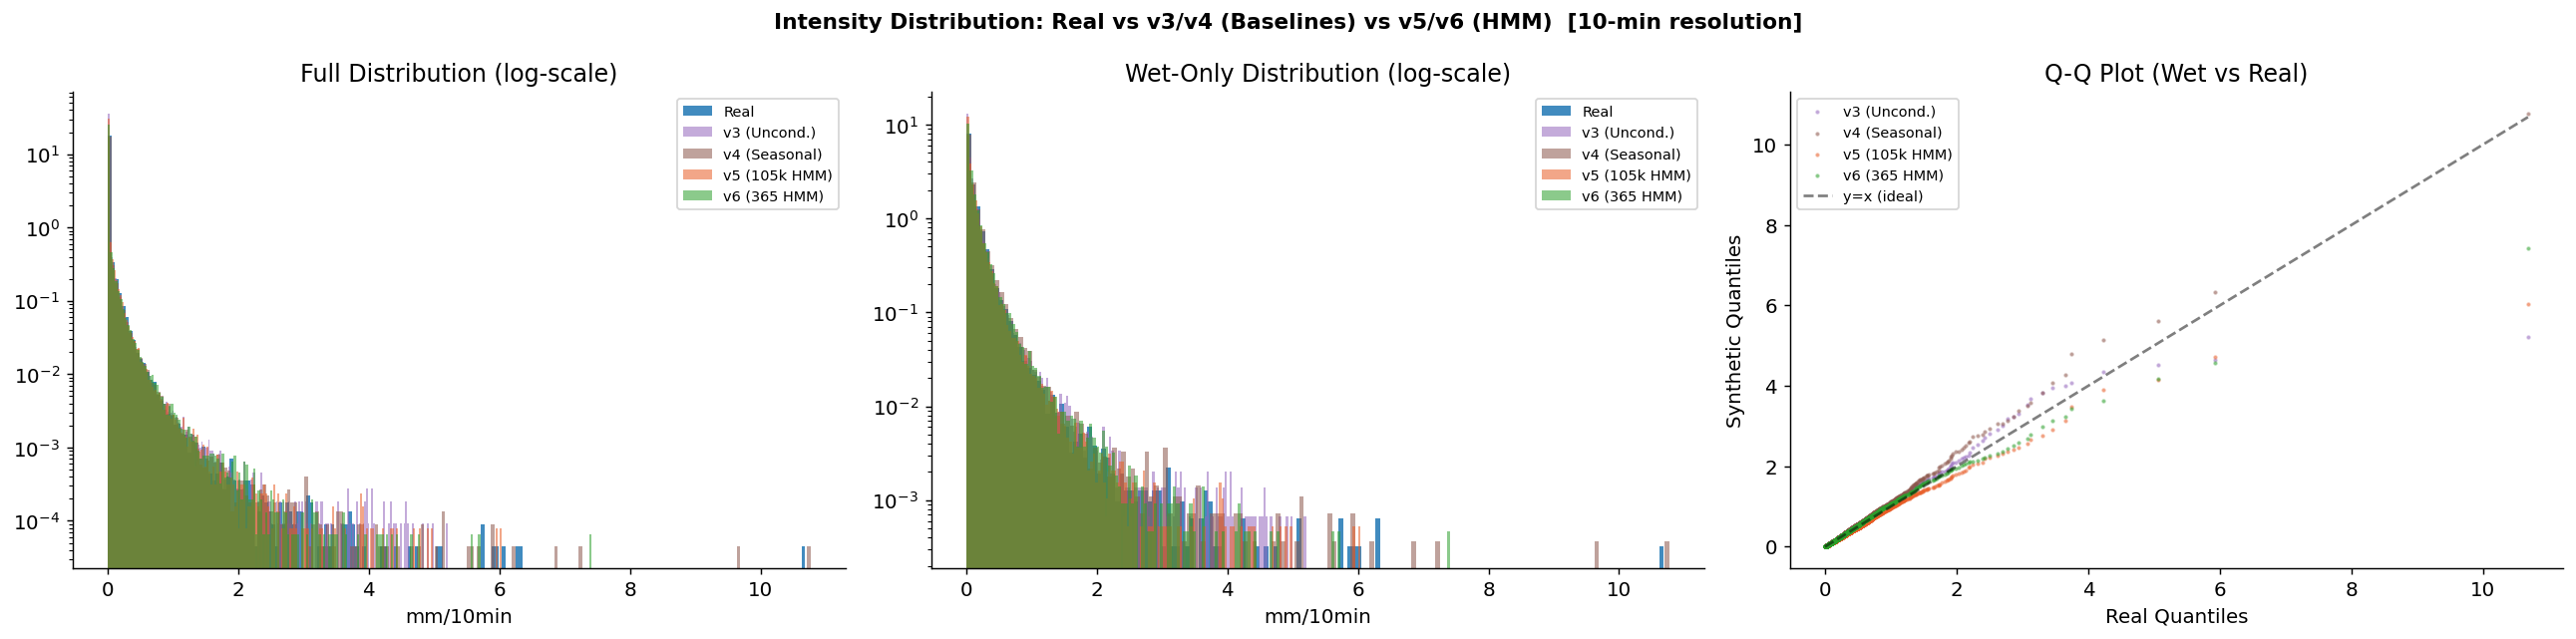


  Dataset                    KS stat        KS p         JSD
  ----------------------------------------------------------
  v3 (Uncond.)               0.06805    1.34e-87     0.03831
  v4 (Seasonal)              0.09072   1.58e-147     0.03869
  v5 (105k HMM)              0.08169   2.72e-133     0.03522
  v6 (365 HMM)               0.06973    4.08e-93     0.02992


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Intensity Distribution: Real vs v3/v4 (Baselines) vs v5/v6 (HMM)  [10-min resolution]',
             fontsize=12, fontweight='bold')

# Full distribution
for label, arr in DATASETS.items():
    axes[0].hist(arr, bins=200, density=True, alpha=ALPHAS[label], label=label, color=COLORS[label])
axes[0].set_yscale('log'); axes[0].set_title('Full Distribution (log-scale)')
axes[0].set_xlabel('mm/10min'); axes[0].legend(fontsize=8)

# Wet-only
for label, arr in NZ.items():
    axes[1].hist(arr, bins=150, density=True, alpha=ALPHAS[label], label=label, color=COLORS[label])
axes[1].set_yscale('log'); axes[1].set_title('Wet-Only Distribution (log-scale)')
axes[1].set_xlabel('mm/10min'); axes[1].legend(fontsize=8)

# QQ plot against real
real_nz = NZ['Real']
n_qq = min(10000, min(len(v) for v in NZ.values()))
q_r = np.quantile(np.sort(real_nz), np.linspace(0, 1, n_qq))
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    q_s = np.quantile(np.sort(NZ[label]), np.linspace(0, 1, n_qq))
    axes[2].scatter(q_r, q_s, s=2, alpha=0.4, label=label, color=COLORS[label])
axes[2].plot([0, q_r.max()], [0, q_r.max()], 'k--', alpha=0.5, label='y=x (ideal)')
axes[2].set_title('Q-Q Plot (Wet vs Real)'); axes[2].set_xlabel('Real Quantiles')
axes[2].set_ylabel('Synthetic Quantiles'); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

# KS + JSD
bins = np.linspace(0.001, max(v.max() for v in NZ.values()), 200)
hr, _ = np.histogram(real_nz, bins=bins, density=True); hr += 1e-12

print(f'\n  {"Dataset":22s}  {"KS stat":>10s}  {"KS p":>10s}  {"JSD":>10s}')
print('  ' + '-'*58)
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    ks, p = stats.ks_2samp(real_nz, NZ[label])
    hs, _ = np.histogram(NZ[label], bins=bins, density=True); hs += 1e-12
    jsd   = jensenshannon(hr, hs)
    print(f'  {label:22s}  {ks:>10.5f}  {p:>10.2e}  {jsd:>10.5f}')

## 4. Wet/Dry Spell Analysis

,Num wet spells,Mean wet (min),Median wet (min),Max wet (min),Num dry spells,Mean dry (hrs),Median dry (hrs),Max dry (hrs)
Dataset,,,,,,,,
Real,7596,57.86000,30.00000,2220,7596,8.24000,1.17000,801.50000
v3 (Uncond.),10604,40.23000,20.00000,520,10604,5.92000,1.50000,93.67000
v4 (Seasonal),11681,33.00000,20.00000,310,11682,5.43000,1.50000,83.00000
v5 (105k HMM),10880,43.88000,30.00000,340,10881,5.69000,3.00000,75.67000
v6 (365 HMM),10083,43.37000,30.00000,340,10084,6.21000,3.33000,73.00000


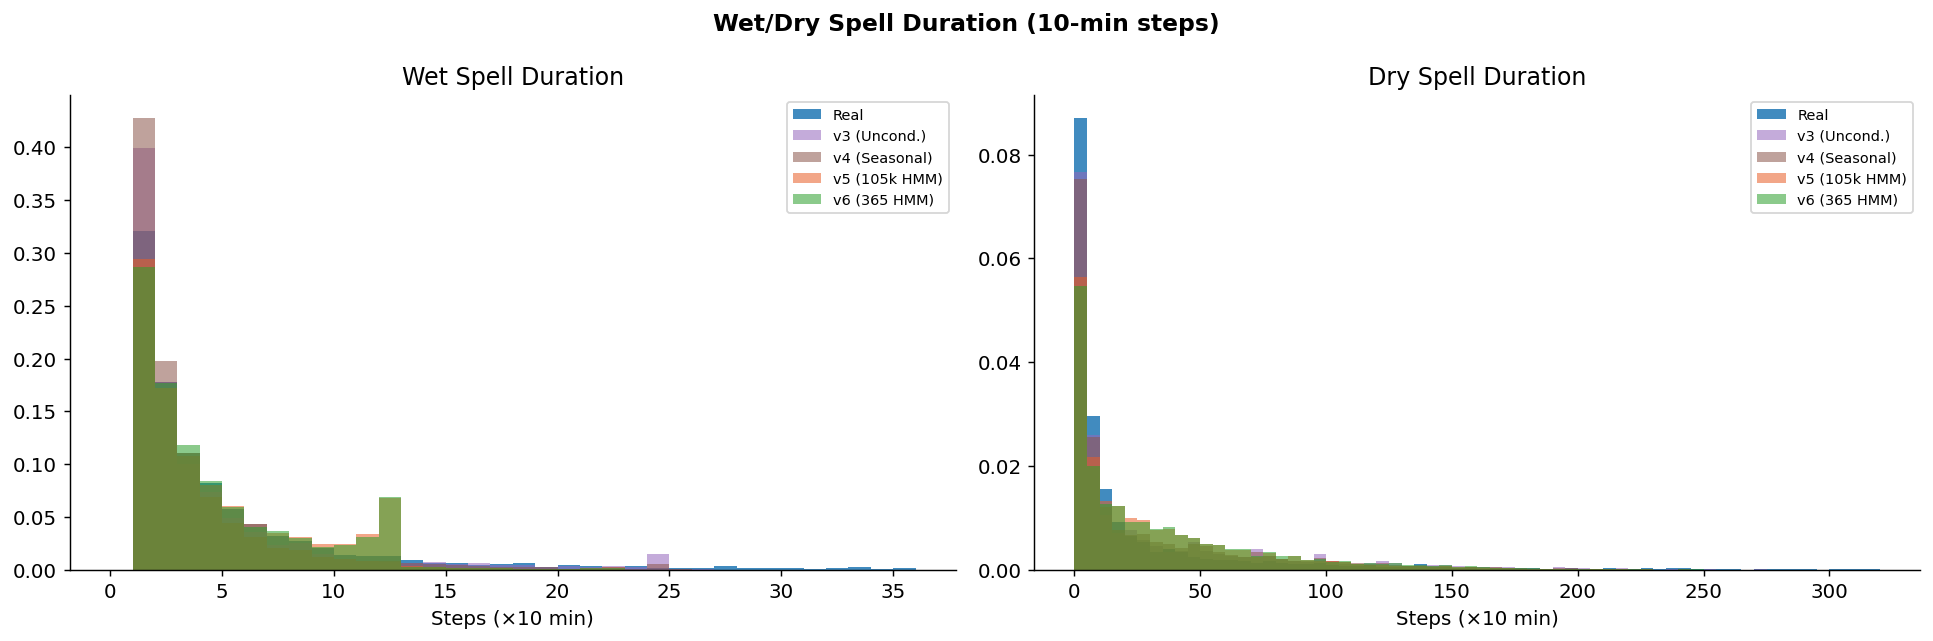


── KS Tests vs Real ──────────────────────────────────────────
  v3 (Uncond.)          : Wet KS=0.0870 (p=1.36e-29)   Dry KS=0.0878 (p=4.01e-30)
  v4 (Seasonal)         : Wet KS=0.1360 (p=1.02e-74)   Dry KS=0.0842 (p=7.87e-29)
  v5 (105k HMM)         : Wet KS=0.0805 (p=1.15e-25)   Dry KS=0.1865 (p=1.01e-136)
  v6 (365 HMM)          : Wet KS=0.0825 (p=4.54e-26)   Dry KS=0.2074 (p=6.28e-164)


In [16]:
def extract_spells(arr):
    is_wet  = (arr > 0).astype(int)
    changes = np.diff(is_wet, prepend=-1)
    starts  = np.where(changes != 0)[0]
    lengths = np.diff(np.append(starts, len(arr)))
    types   = is_wet[starts]
    return lengths[types == 1], lengths[types == 0]

SPELLS = {l: extract_spells(a) for l, a in DATASETS.items()}

spell_df = pd.DataFrame([
    {
        'Dataset'              : l,
        'Num wet spells'       : len(SPELLS[l][0]),
        'Mean wet (min)'       : SPELLS[l][0].mean() * STEP_MIN,
        'Median wet (min)'     : np.median(SPELLS[l][0]) * STEP_MIN,
        'Max wet (min)'        : SPELLS[l][0].max() * STEP_MIN,
        'Num dry spells'       : len(SPELLS[l][1]),
        'Mean dry (hrs)'       : SPELLS[l][1].mean() * STEP_MIN / 60,
        'Median dry (hrs)'     : np.median(SPELLS[l][1]) * STEP_MIN / 60,
        'Max dry (hrs)'        : SPELLS[l][1].max() * STEP_MIN / 60,
    } for l in DATASETS
]).set_index('Dataset')
display(spell_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Wet/Dry Spell Duration ({STEP_MIN}-min steps)', fontsize=13, fontweight='bold')

all_wet = np.concatenate([SPELLS[l][0] for l in DATASETS])
all_dry = np.concatenate([SPELLS[l][1] for l in DATASETS])
max_wet = int(np.percentile(all_wet, 99.5) * 1.2)
max_dry = int(np.percentile(all_dry, 99) * 1.2)

for label, (wet, dry) in SPELLS.items():
    axes[0].hist(wet, bins=np.arange(0, max_wet+1), density=True,
                 alpha=ALPHAS[label], label=label, color=COLORS[label])
    axes[1].hist(dry, bins=np.arange(0, max_dry+1, max(1, max_dry//60)), density=True,
                 alpha=ALPHAS[label], label=label, color=COLORS[label])

axes[0].set_title('Wet Spell Duration'); axes[0].set_xlabel(f'Steps (×{STEP_MIN} min)'); axes[0].legend(fontsize=8)
axes[1].set_title('Dry Spell Duration'); axes[1].set_xlabel(f'Steps (×{STEP_MIN} min)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print('\n── KS Tests vs Real ──────────────────────────────────────────')
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    kw, pw  = stats.ks_2samp(SPELLS['Real'][0], SPELLS[label][0])
    kd, pd_ = stats.ks_2samp(SPELLS['Real'][1], SPELLS[label][1])
    print(f'  {label:22s}: Wet KS={kw:.4f} (p={pw:.2e})   Dry KS={kd:.4f} (p={pd_:.2e})')

## 5. Temporal Autocorrelation

Computing ACFs (this takes ~30–60s)...
Done.


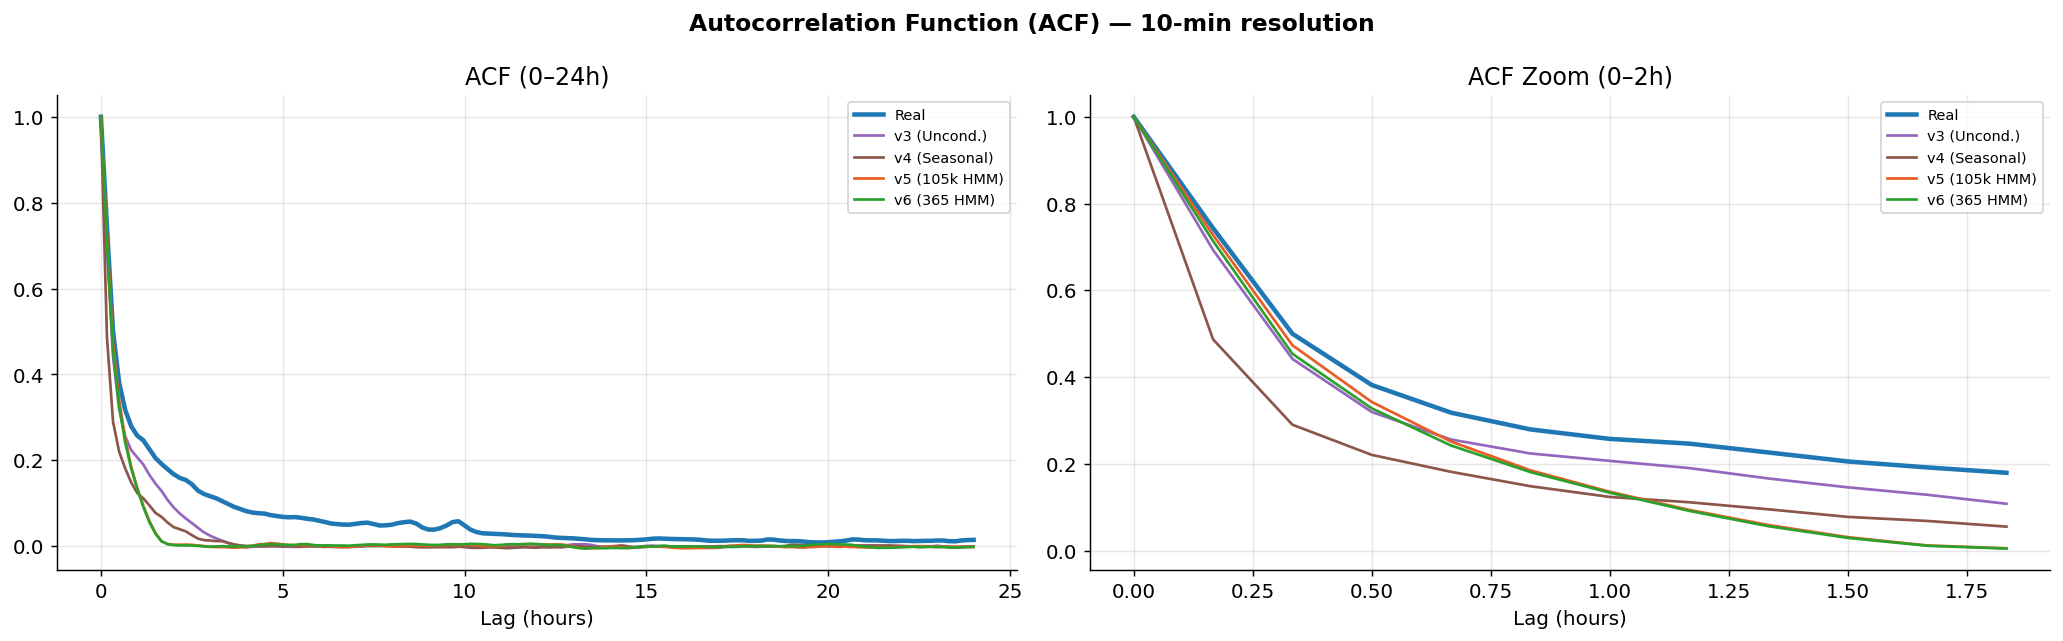


── ACF Error vs Real (lower = better) ───────────────────────
  Dataset                        MAE        RMSE
  ----------------------------------------------
  v3 (Uncond.)               0.03613     0.04447
  v4 (Seasonal)              0.04481     0.06230
  v5 (105k HMM)              0.04259     0.05930
  v6 (365 HMM)               0.04225     0.05937


In [17]:
def compute_acf(arr, max_lag=144):  # 144 × 10-min = 24 hours
    mean, var = arr.mean(), arr.var()
    n = len(arr)
    return np.array([np.mean((arr[:n-k]-mean)*(arr[k:]-mean))/var if var > 0 else 0
                     for k in range(max_lag + 1)])

MAX_LAG = 144  # 24 hours at 10-min
print('Computing ACFs (this takes ~30–60s)...')
ACFs = {l: compute_acf(a, MAX_LAG) for l, a in DATASETS.items()}
print('Done.')

lags_hours = np.arange(MAX_LAG + 1) * STEP_MIN / 60

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Autocorrelation Function (ACF) — 10-min resolution', fontsize=13, fontweight='bold')

for label, acf in ACFs.items():
    lw = 2.5 if label == 'Real' else 1.5
    axes[0].plot(lags_hours, acf, label=label, color=COLORS[label], linewidth=lw)
    axes[1].plot(lags_hours[:12], acf[:12], label=label, color=COLORS[label], linewidth=lw)

axes[0].set_title('ACF (0–24h)'); axes[0].set_xlabel('Lag (hours)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title('ACF Zoom (0–2h)'); axes[1].set_xlabel('Lag (hours)'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('\n── ACF Error vs Real (lower = better) ───────────────────────')
print(f'  {"Dataset":22s}  {"MAE":>10s}  {"RMSE":>10s}')
print('  ' + '-'*46)
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    mae  = np.abs(ACFs['Real'] - ACFs[label]).mean()
    rmse = np.sqrt(((ACFs['Real'] - ACFs[label])**2).mean())
    print(f'  {label:22s}  {mae:>10.5f}  {rmse:>10.5f}')

## 6. Extreme Value Analysis

,Real,v3 (Uncond.),v4 (Seasonal),v5 (105k HMM),v6 (365 HMM),v3 (Uncond.)/Real,v4 (Seasonal)/Real,v5 (105k HMM)/Real,v6 (365 HMM)/Real
Percentile,,,,,,,,,
90.00000,0.00750,0.00540,0.00000,0.00817,0.00664,0.72029,0.00000,1.08872,0.88567
95.00000,0.06000,0.04960,0.05141,0.06125,0.05642,0.82674,0.85678,1.02078,0.94027
99.00000,0.31750,0.31231,0.32643,0.31451,0.33405,0.98364,1.02812,0.99059,1.05213
99.50000,0.49250,0.49794,0.51190,0.47852,0.51762,1.01105,1.03938,0.97161,1.05101
99.90000,1.09168,1.17621,1.14446,1.10607,1.15698,1.07743,1.04835,1.01318,1.05982


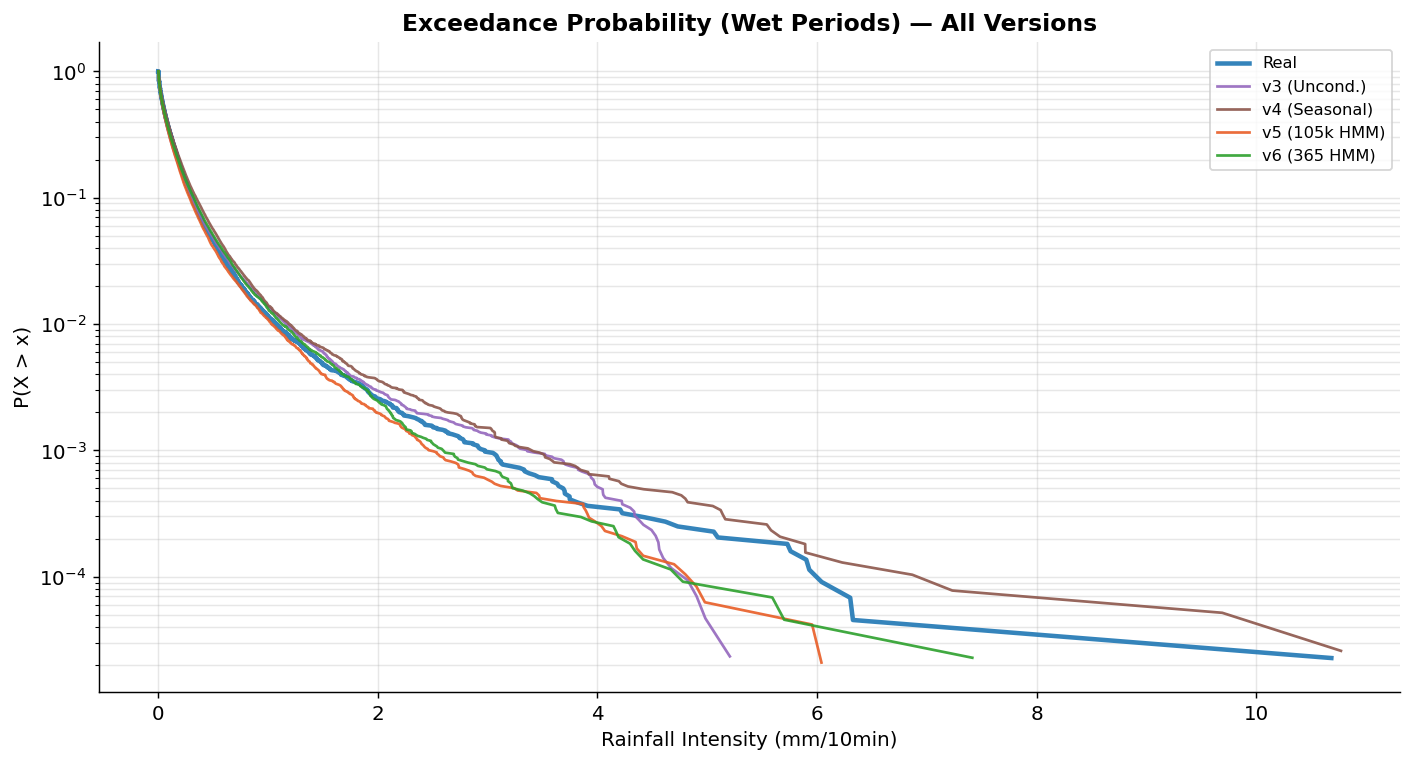

In [18]:
percentiles = [90, 95, 99, 99.5, 99.9]

rows = []
for p in percentiles:
    row = {'Percentile': p}
    for l, a in DATASETS.items():
        row[l] = np.percentile(a, p)
    real_val = row['Real']
    for l in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
        row[f'{l}/Real'] = row[l] / real_val if real_val > 0 else float('inf')
    rows.append(row)
display(pd.DataFrame(rows).set_index('Percentile').round(5))

# Exceedance probability
fig, ax = plt.subplots(figsize=(11, 6))
for label, arr in NZ.items():
    s = np.sort(arr)[::-1]
    p = np.arange(1, len(s)+1) / len(s)
    lw = 2.5 if label == 'Real' else 1.5
    ax.semilogy(s, p, label=label, color=COLORS[label], linewidth=lw, alpha=0.9)
ax.set_title('Exceedance Probability (Wet Periods) — All Versions', fontsize=13, fontweight='bold')
ax.set_xlabel(f'Rainfall Intensity (mm/{STEP_MIN}min)'); ax.set_ylabel('P(X > x)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## 7. Storm Event Analysis

,N storms,Mean dur (min),Median dur (min),Mean peak (mm),Max peak (mm),Mean vol (mm),Mean peak pos
Dataset,,,,,,,
Real,3880,100.28600,60.00000,0.30300,10.68200,1.44600,0.37000
v3 (Uncond.),4494,77.13800,50.00000,0.31600,5.20700,1.16800,0.39000
v4 (Seasonal),4378,66.10300,50.00000,0.37300,10.77000,1.12700,0.37500
v5 (105k HMM),5810,70.23100,60.00000,0.26500,6.04100,0.95200,0.39200
v6 (365 HMM),5417,68.82600,60.00000,0.29600,7.41400,1.02800,0.38500


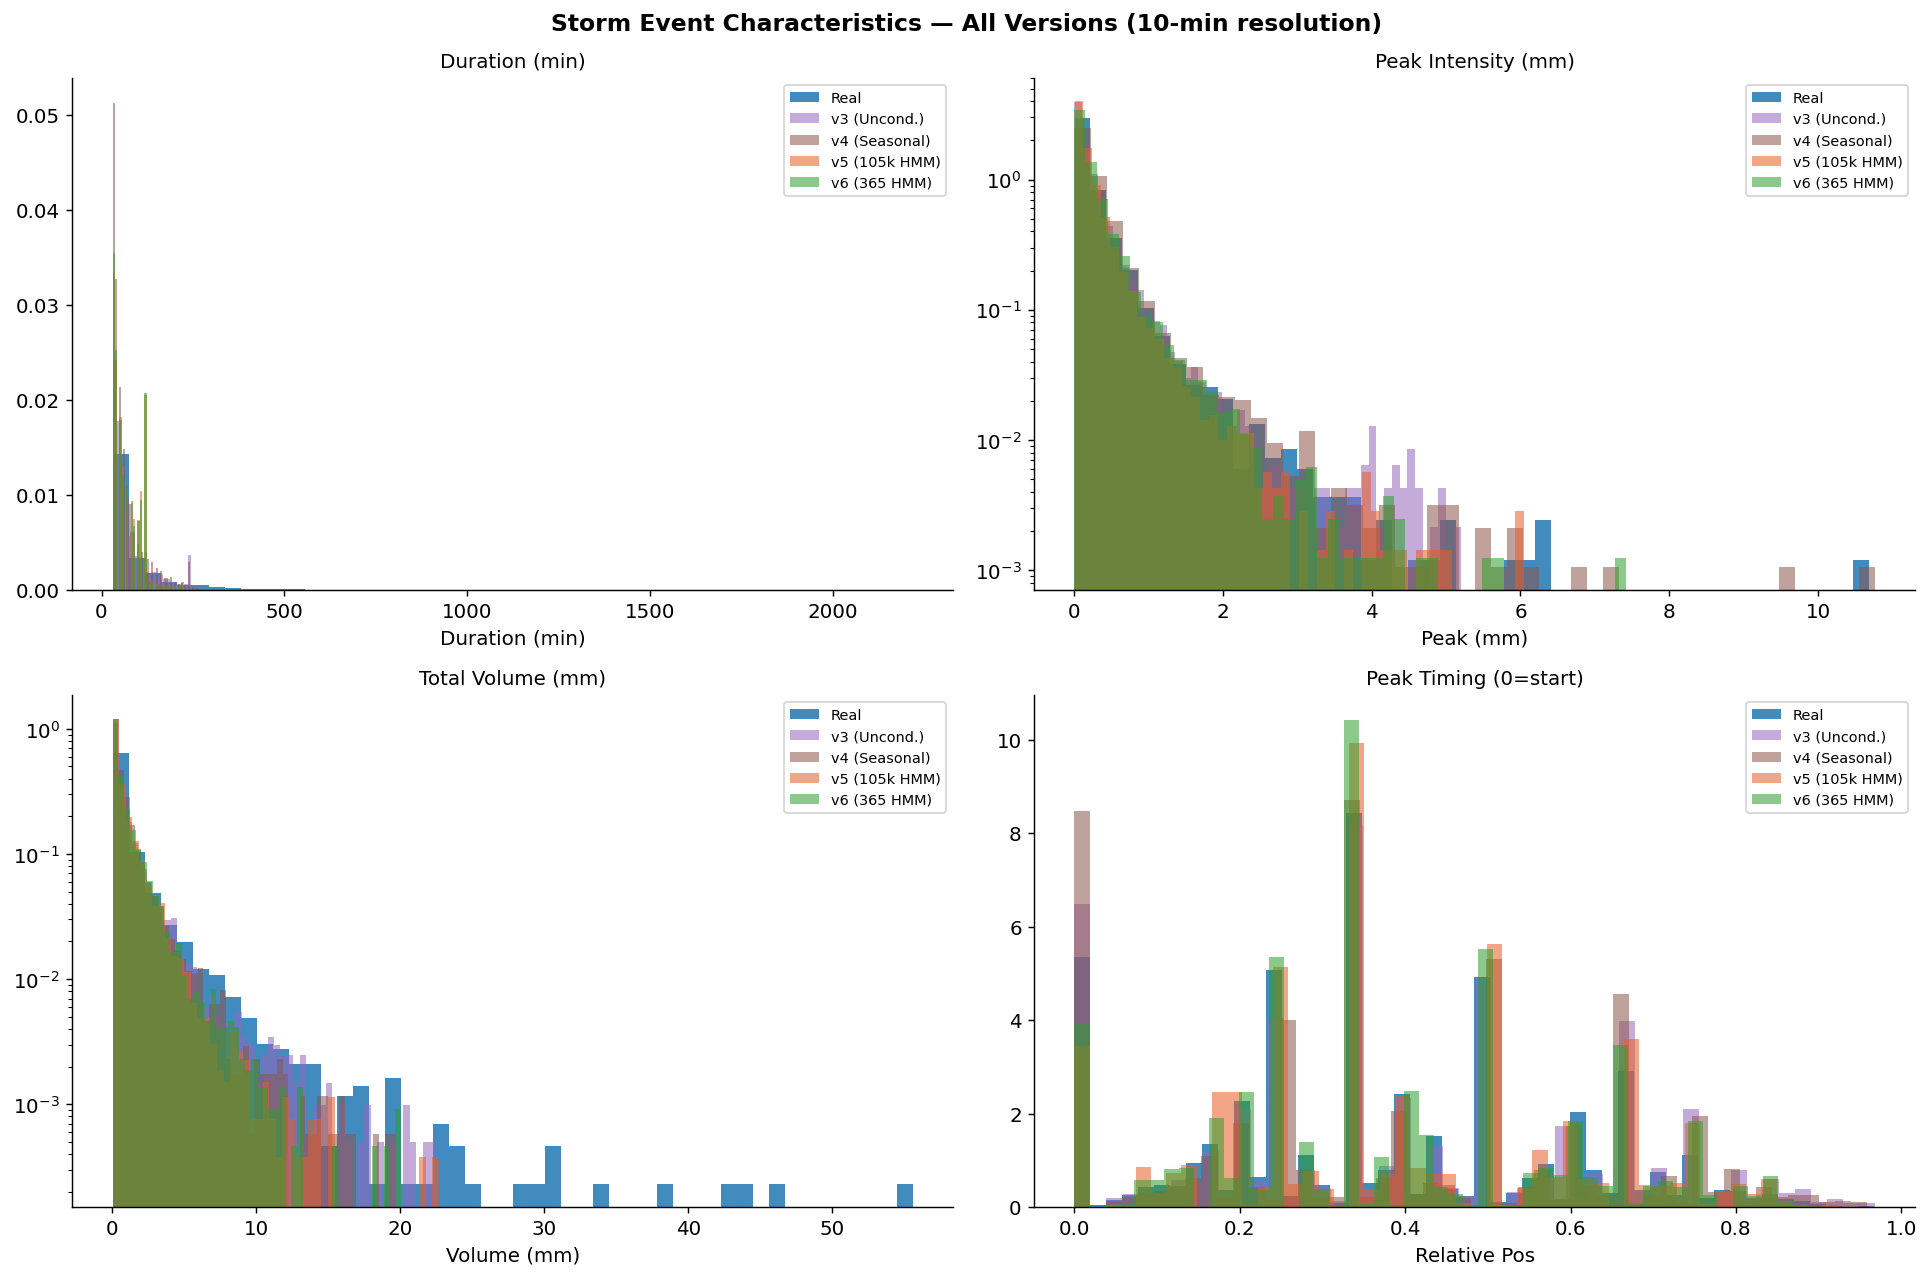


── Storm KS Tests vs Real ────────────────────────────────────
  v3 (Uncond.)          : Dur KS=0.0712  Peak KS=0.0507  Vol KS=0.0297
  v4 (Seasonal)         : Dur KS=0.1077  Peak KS=0.1432  Vol KS=0.1092
  v5 (105k HMM)         : Dur KS=0.1595  Peak KS=0.0412  Vol KS=0.0580
  v6 (365 HMM)          : Dur KS=0.1633  Peak KS=0.0605  Vol KS=0.0497


In [19]:
def extract_storms(arr, min_dur=3):
    is_wet  = (arr > 0).astype(int)
    changes = np.diff(is_wet, prepend=-1)
    starts  = np.where(changes != 0)[0]
    lengths = np.diff(np.append(starts, len(arr)))
    types   = is_wet[starts]
    return [arr[s:s+l] for s, l, t in zip(starts, lengths, types) if t == 1 and l >= min_dur]

STORMS = {l: extract_storms(a) for l, a in DATASETS.items()}

storm_df = pd.DataFrame([
    {
        'Dataset'           : l,
        'N storms'          : len(STORMS[l]),
        'Mean dur (min)'    : np.mean([len(s)*STEP_MIN for s in STORMS[l]]),
        'Median dur (min)'  : np.median([len(s)*STEP_MIN for s in STORMS[l]]),
        'Mean peak (mm)'    : np.mean([s.max() for s in STORMS[l]]),
        'Max peak (mm)'     : np.max([s.max() for s in STORMS[l]]),
        'Mean vol (mm)'     : np.mean([s.sum() for s in STORMS[l]]),
        'Mean peak pos'     : np.mean([np.argmax(s)/len(s) for s in STORMS[l]]),
    } for l in DATASETS
]).set_index('Dataset')
display(storm_df.round(3))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Storm Event Characteristics — All Versions (10-min resolution)', fontsize=13, fontweight='bold')

plots = [
    ('Duration (min)',         (0,0), lambda ss: np.array([len(s)*STEP_MIN for s in ss]), 'Duration (min)', False),
    ('Peak Intensity (mm)',    (0,1), lambda ss: np.array([s.max() for s in ss]),          'Peak (mm)',       True),
    ('Total Volume (mm)',      (1,0), lambda ss: np.array([s.sum() for s in ss]),          'Volume (mm)',     True),
    ('Peak Timing (0=start)', (1,1), lambda ss: np.array([np.argmax(s)/len(s) for s in ss]), 'Relative Pos', False),
]
for title, idx, fn, xlabel, log_y in plots:
    ax = axes[idx]
    for label, storms in STORMS.items():
        vals = fn(storms)
        ax.hist(vals, bins=50, density=True, alpha=ALPHAS[label], label=label, color=COLORS[label])
    ax.set_title(title, fontsize=11); ax.set_xlabel(xlabel); ax.legend(fontsize=8)
    if log_y: ax.set_yscale('log')

plt.tight_layout(); plt.show()

print('\n── Storm KS Tests vs Real ────────────────────────────────────')
dur_r  = np.array([len(s)*STEP_MIN for s in STORMS['Real']])
peak_r = np.array([s.max() for s in STORMS['Real']])
vol_r  = np.array([s.sum() for s in STORMS['Real']])
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    dur_s  = np.array([len(s)*STEP_MIN for s in STORMS[label]])
    peak_s = np.array([s.max() for s in STORMS[label]])
    vol_s  = np.array([s.sum() for s in STORMS[label]])
    kd, _  = stats.ks_2samp(dur_r,  dur_s)
    kp, _  = stats.ks_2samp(peak_r, peak_s)
    kv, _  = stats.ks_2samp(vol_r,  vol_s)
    print(f'  {label:22s}: Dur KS={kd:.4f}  Peak KS={kp:.4f}  Vol KS={kv:.4f}')

## 8. Sample Timeseries Visual

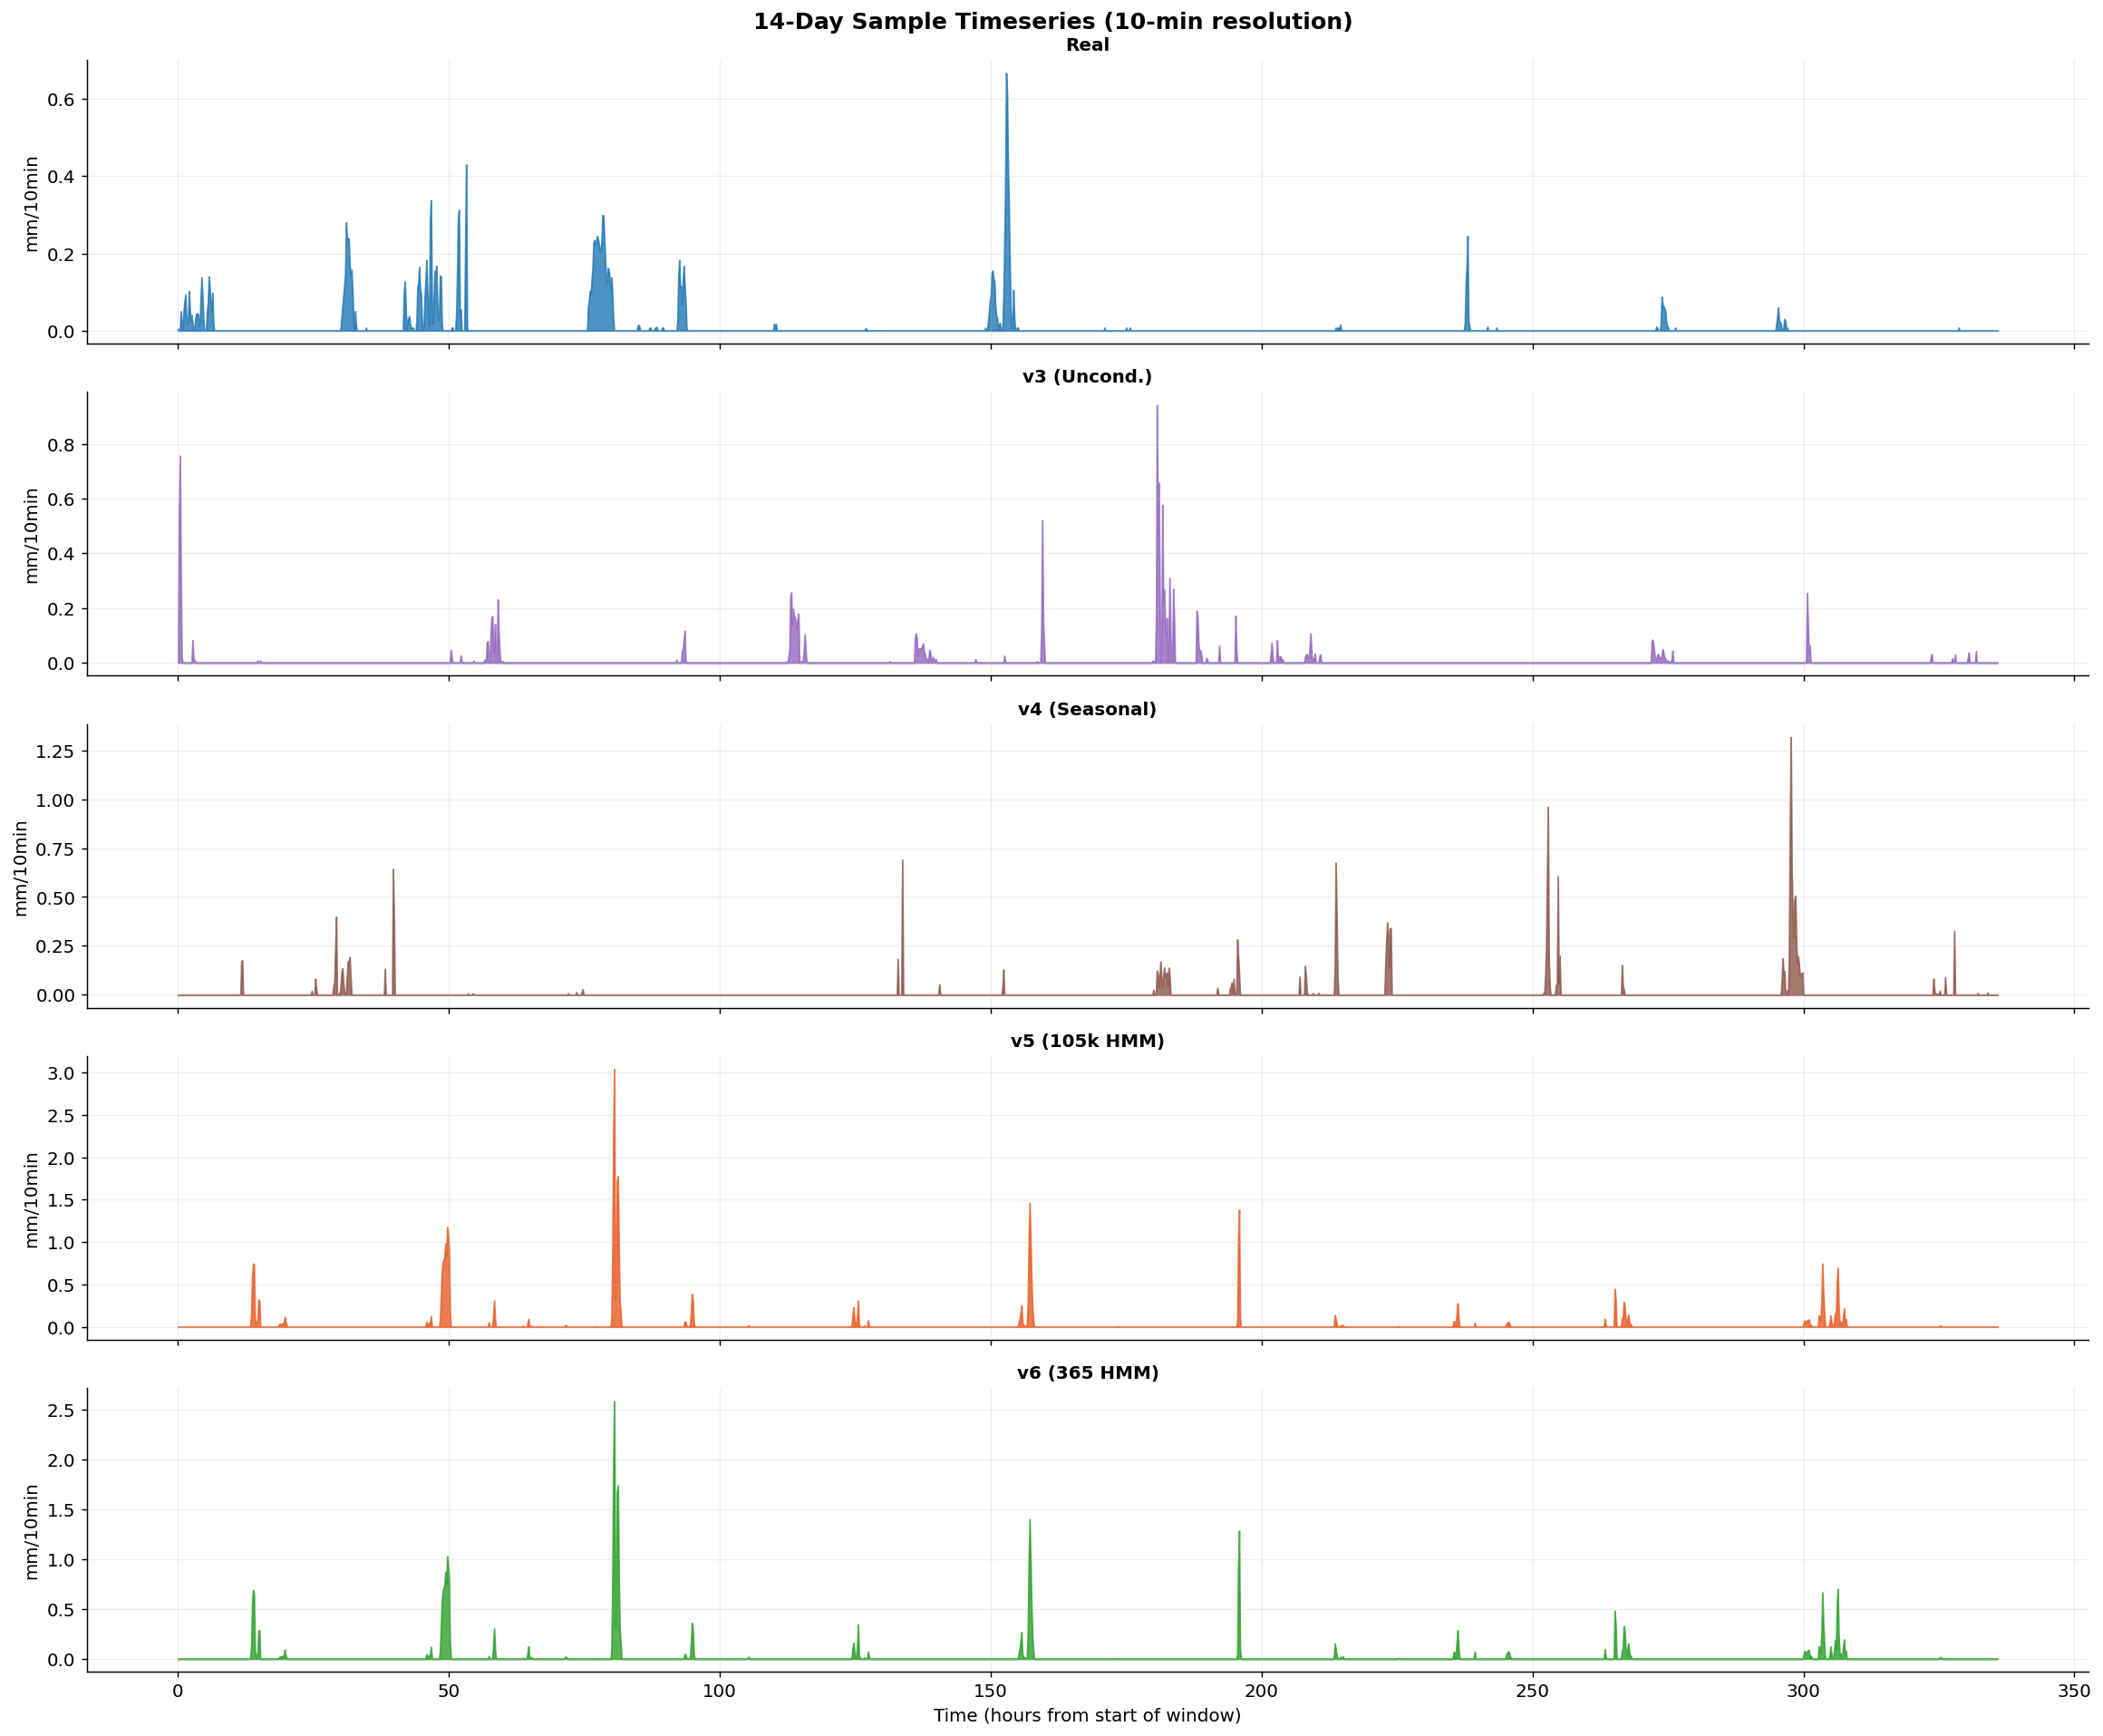

In [20]:
STEPS_PER_DAY = int(24 * 60 / STEP_MIN)  # 144 at 10-min
WINDOW = STEPS_PER_DAY * 14

def find_rainy(arr, window, min_total=5):
    for start in range(0, len(arr)-window, STEPS_PER_DAY):
        if arr[start:start+window].sum() > min_total:
            return arr[start:start+window]
    return arr[:window]

hours = np.arange(WINDOW) * STEP_MIN / 60
fig, axes = plt.subplots(5, 1, figsize=(18, 15), sharex=True)
fig.suptitle(f'14-Day Sample Timeseries ({STEP_MIN}-min resolution)', fontsize=14, fontweight='bold')

for ax, (label, arr) in zip(axes, DATASETS.items()):
    w = find_rainy(arr, WINDOW)
    ax.fill_between(hours, w, alpha=0.8, color=COLORS[label])
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel(f'mm/{STEP_MIN}min'); ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (hours from start of window)')
plt.tight_layout(); plt.show()

## 9. RL-Fitness Scorecard — Full Ablation

In [21]:
def compute_scores(label, synth, synth_nz, acf_s):
    real_nz = NZ['Real']
    scores  = {}

    # Wet/dry ratio
    err = abs((real > 0).mean() - (synth > 0).mean()) / (real > 0).mean()
    scores['Wet/Dry Ratio']        = max(0, 1 - err * 5)

    # Mean intensity (wet)
    err = abs(real_nz.mean() - synth_nz.mean()) / real_nz.mean()
    scores['Mean Intensity (wet)'] = max(0, 1 - err * 2)

    # JSD (wet-only)
    bins = np.linspace(0.001, max(real_nz.max(), synth_nz.max()), 200)
    hr, _ = np.histogram(real_nz,  bins=bins, density=True); hr += 1e-12
    hs, _ = np.histogram(synth_nz, bins=bins, density=True); hs += 1e-12
    scores['Distribution (JSD)']   = max(0, 1 - jensenshannon(hr, hs) * 4)

    # ACF
    scores['Autocorrelation']      = max(0, 1 - np.abs(ACFs['Real'] - acf_s).mean() * 10)

    # Storm duration
    dur_r = np.array([len(s) for s in STORMS['Real']])
    dur_s = np.array([len(s) for s in STORMS[label]])
    err   = abs(dur_r.mean() - dur_s.mean()) / dur_r.mean()
    scores['Storm Duration']       = max(0, 1 - err * 3)

    # P99
    ratio = np.percentile(synth_nz, 99) / np.percentile(real_nz, 99)
    scores['Extreme Values (P99)'] = max(0, 1 - abs(1 - ratio) * 3)

    # Storm count
    ratio = len(STORMS[label]) / len(STORMS['Real'])
    scores['Storm Count']          = max(0, 1 - abs(1 - ratio) * 2)

    # Peak timing
    pp_r = np.mean([np.argmax(s)/len(s) for s in STORMS['Real']])
    pp_s = np.mean([np.argmax(s)/len(s) for s in STORMS[label]])
    scores['Peak Timing']          = max(0, 1 - abs(pp_r - pp_s) * 5)

    return scores

SYNTH_LABELS = ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']
SCORES = {l: compute_scores(l, DATASETS[l], NZ[l], ACFs[l]) for l in SYNTH_LABELS}

dims = list(next(iter(SCORES.values())).keys())
print(f'  {"Dimension":30s}  {"v3":>8s}  {"v4":>8s}  {"v5":>8s}  {"v6":>8s}')
print('  ' + '-'*68)
for d in dims:
    vals = [SCORES[l][d] for l in SYNTH_LABELS]
    best = max(vals)
    row  = '  ' + f'{d:30s}'
    for l, v in zip(SYNTH_LABELS, vals):
        flag = ' ◀' if v == best else '  '
        row += f'  {v:>6.3f}{flag}'
    print(row)

ov = {l: np.mean(list(s.values())) for l, s in SCORES.items()}
print('  ' + '-'*68)
print(f'  {"OVERALL":30s}  ' + '  '.join(f'{ov[l]:>8.3f}' for l in SYNTH_LABELS))
print()
for label, score in ov.items():
    verdict = '✅ FIT' if score >= 0.7 else ('⚠️  CONDITIONAL' if score >= 0.5 else '❌ NOT FIT')
    print(f'  {label}: {verdict} (score={score:.3f})')

  Dimension                             v3        v4        v5        v6
  --------------------------------------------------------------------
  Wet/Dry Ratio                    0.853     0.386     0.569     0.974 ◀
  Mean Intensity (wet)             0.967     0.768     0.831     0.984 ◀
  Distribution (JSD)               0.835     0.845     0.845     0.873 ◀
  Autocorrelation                  0.639 ◀   0.552     0.574     0.577  
  Storm Duration                   0.308 ◀   0.000     0.101     0.059  
  Extreme Values (P99)             0.746     0.672     0.879 ◀   0.850  
  Storm Count                      0.684     0.743 ◀   0.005     0.208  
  Peak Timing                      0.902     0.975 ◀   0.894     0.928  
  --------------------------------------------------------------------
  OVERALL                            0.741     0.618     0.587     0.682

  v3 (Uncond.): ✅ FIT (score=0.741)
  v4 (Seasonal): ⚠️  CONDITIONAL (score=0.618)
  v5 (105k HMM): ⚠️  CONDITIONAL (score=0.58

## 10. Visual Scorecard: Improvement Over Baseline (v3)

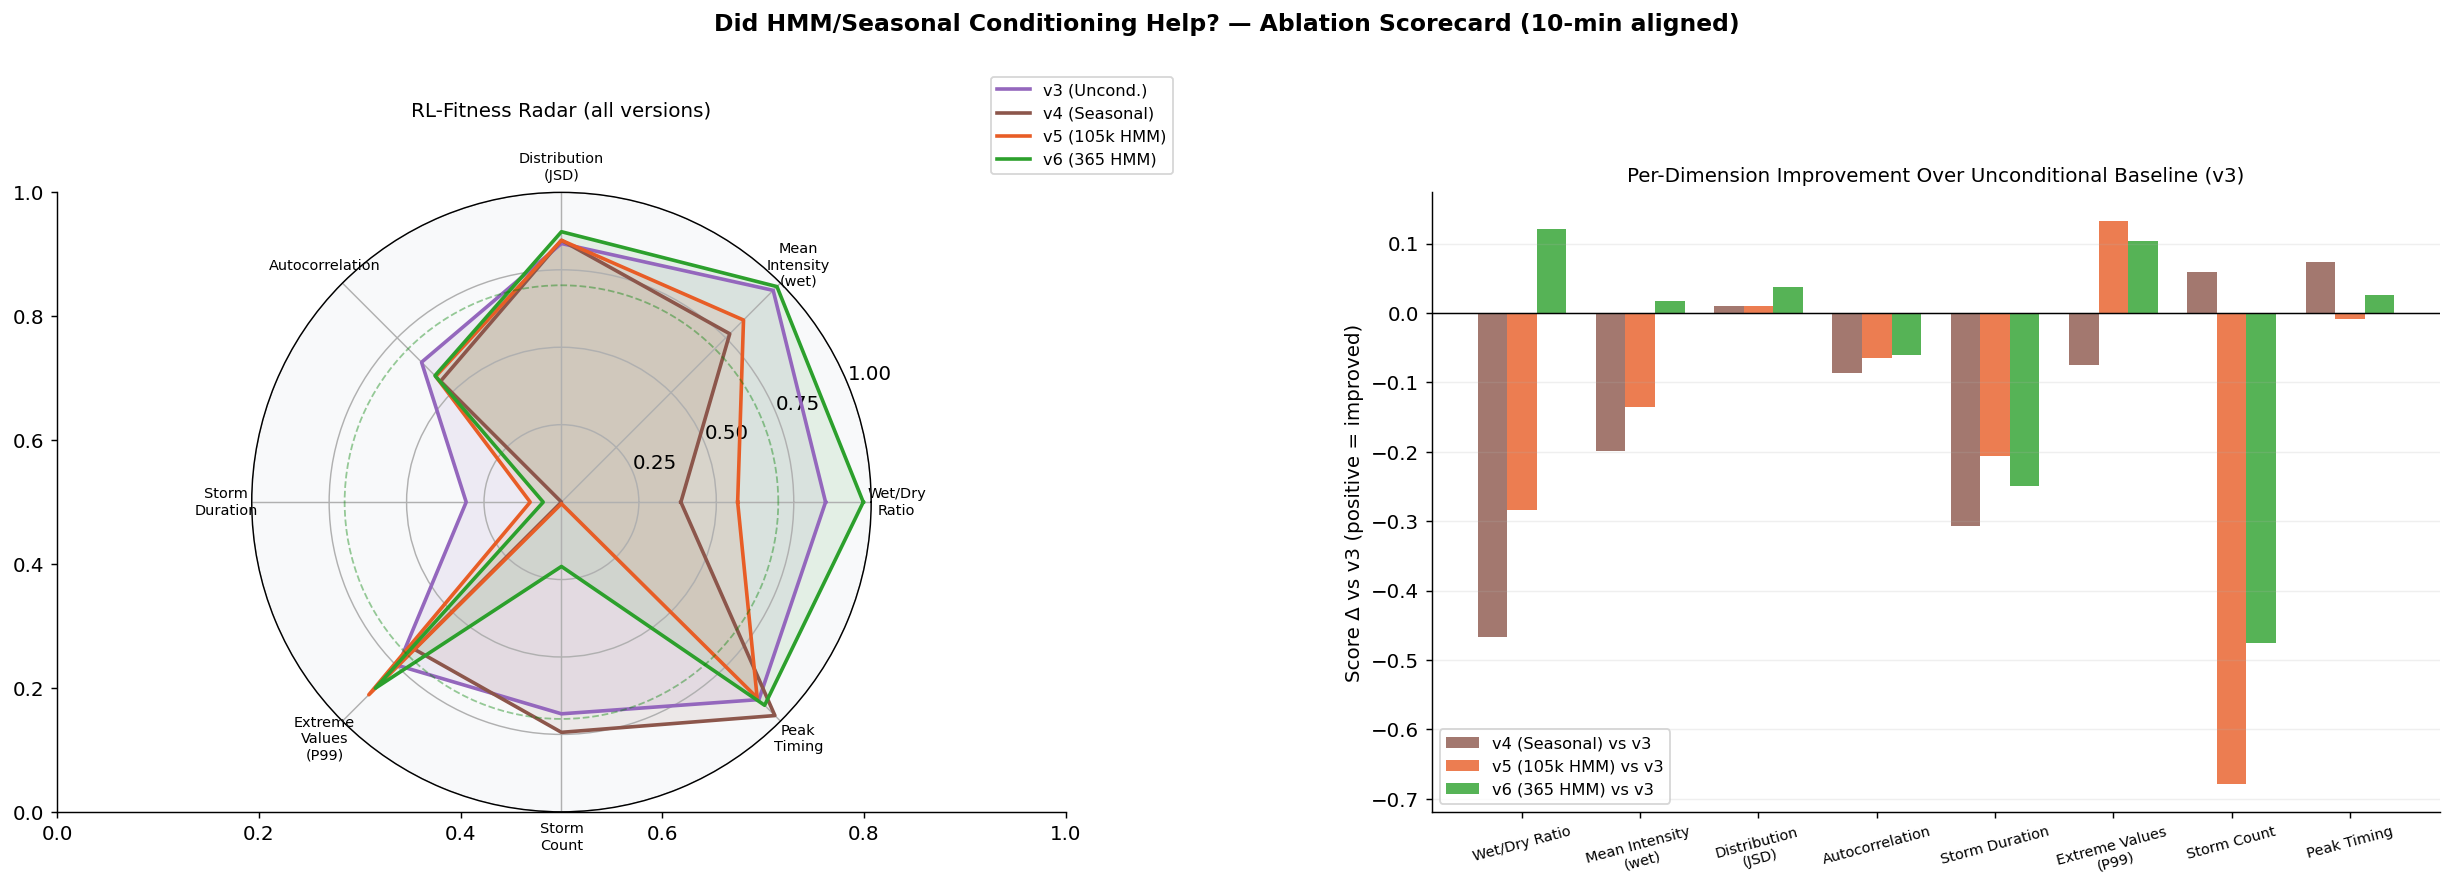


── Improvement Over v3 Summary ──────────────────────────────────
  v4 (Seasonal)         : improved in 3/8 dims  |  overall Δ = -0.124 ↓
  v5 (105k HMM)         : improved in 2/8 dims  |  overall Δ = -0.154 ↓
  v6 (365 HMM)          : improved in 5/8 dims  |  overall Δ = -0.060 ↓

  Overall scores:
    v3 (Uncond.): 0.741
    v4 (Seasonal): 0.618
    v5 (105k HMM): 0.587
    v6 (365 HMM): 0.682


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(19, 7))
fig.suptitle('Did HMM/Seasonal Conditioning Help? — Ablation Scorecard (10-min aligned)',
             fontsize=13, fontweight='bold')

# ── Left: Radar chart ──────────────────────────────────────────────────────
ax = plt.subplot(121, polar=True)
ax.set_facecolor('#f8f9fa')
N_dims = len(dims)
angles = np.linspace(0, 2*np.pi, N_dims, endpoint=False).tolist() + [0]

for label in SYNTH_LABELS:
    vals = [SCORES[label][d] for d in dims] + [SCORES[label][dims[0]]]
    ax.plot(angles, vals, color=COLORS[label], linewidth=2, label=label)
    ax.fill(angles, vals, color=COLORS[label], alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([d.replace(' ', '\n') for d in dims], size=8)
ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.axhline(0.7, color='green', lw=1, ls='--', alpha=0.4)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.2), fontsize=9)
ax.set_title('RL-Fitness Radar (all versions)', fontsize=11, pad=20)

# ── Right: Bar chart — dimension-wise improvement over v3 ──────────────────
ax2 = axes[1]
x   = np.arange(len(dims))
w   = 0.25
compare_labels = ['v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']
offsets = [-w, 0, w]

for offset, label in zip(offsets, compare_labels):
    imp = [SCORES[label][d] - SCORES['v3 (Uncond.)'][d] for d in dims]
    ax2.bar(x + offset, imp, w, label=f'{label} vs v3', color=COLORS[label], alpha=0.8)

ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([d.replace(' (', '\n(') for d in dims], fontsize=8, rotation=15)
ax2.set_ylabel('Score Δ vs v3 (positive = improved)')
ax2.set_title('Per-Dimension Improvement Over Unconditional Baseline (v3)', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.2, axis='y')

plt.tight_layout(); plt.show()

# Summary
print('\n── Improvement Over v3 Summary ──────────────────────────────────')
for label in compare_labels:
    n_imp = sum(1 for d in dims if SCORES[label][d] > SCORES['v3 (Uncond.)'][d])
    delta = ov[label] - ov['v3 (Uncond.)']
    trend = '↑' if delta > 0 else '↓'
    print(f'  {label:22s}: improved in {n_imp}/{len(dims)} dims  |  overall Δ = {delta:+.3f} {trend}')
print(f'\n  Overall scores:')
for l in SYNTH_LABELS:
    print(f'    {l}: {ov[l]:.3f}')